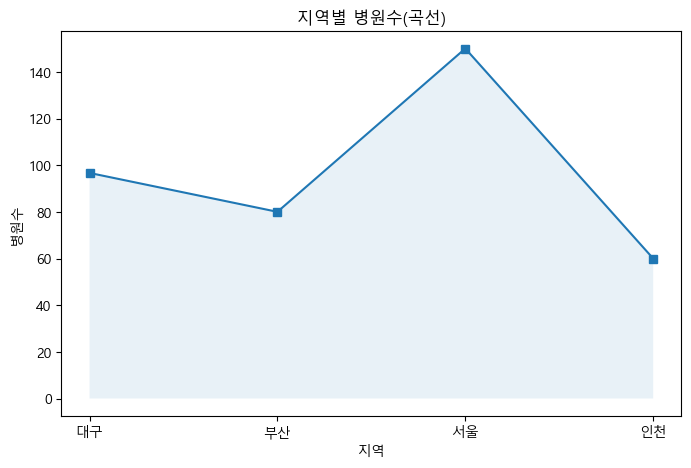

In [12]:
# 01. 반드시 pandas는 import하여 사용
import pandas as pd
# matplotlib 매트플롯립도 반드시 import하여 사용
import matplotlib.pyplot as plt
# 숫자 계산 쉽게하는 라이브러리 불러오기
import numpy as np
# 데이터 사이를 부드럽게 연결해주는 함수
from scipy.interpolate import make_interp_spline

# 02. 데이터 생성하기
df1 = pd.DataFrame({
    "지역": ["서울", "부산", "대구"],
    "총인구": [1000000,300000, 200000]
})

df2 = pd.DataFrame({
    "지역": ["서울", "부산", "인천"],
    "병원수": [150,80, 60]
})

# 03. 데이터 전처리를 위해 merge(병합)
# outer로 병합하면 df1과 df2의 합집합
merged = pd.merge(df1, df2, on="지역", how="outer")
# 04. 결측치 처리
merged["총인구"] = merged["총인구"].fillna(merged["총인구"].mean())
merged["병원수"] = merged["병원수"].fillna(merged["병원수"].mean())

# -----------------------------
# 세로막대 그래프

# 01. 한글 깨짐 방지 설정★
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 02. 그래프 크기 설정
plt.figure(figsize=(8,5))

# 03. 꺽은선 그래프(y축:지역)
plt.plot(merged["지역"],merged["병원수"],marker='s')

# 꺽은선 영역 그래프(색영역 추가)
# fill_between(x,y) => x축 기준으로 선아래 채움
# plt.fill_between(x,y,alpha=0.3) => 투명도 0.1 : 거의 투명, 0.3 : 적당, 1~ : 아주 진함
plt.fill_between(merged['지역'],merged['병원수'],alpha=0.1)

# x축을 숫자로 변환
x = np.arange(len(merged["지역"]))
y = merged["병원수"]
smooth = np.linspace(x.min(),x.max(),300)
smooth02 = make_interp_spline(x,y)(smooth)
# 곡선 그래프
# plt.plot(smooth, smooth02)

# 04. 차트제목, 가로축, 세로축 제목 지정
plt.title("지역별 병원수(곡선)")
plt.xlabel("지역")
plt.ylabel("병원수")

plt.show()


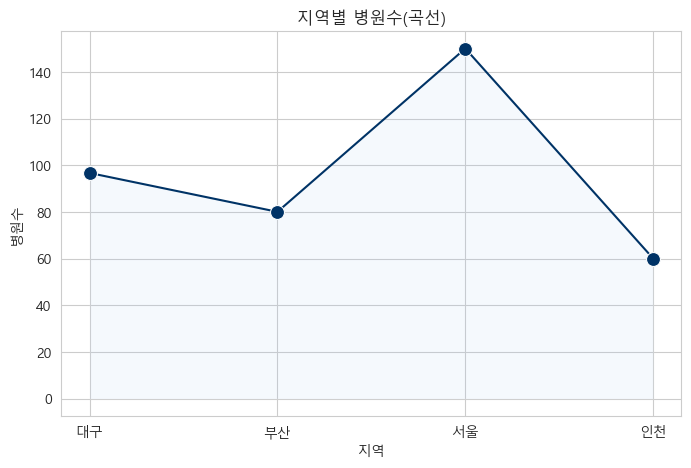

In [3]:
# 01. 반드시 pandas는 import하여 사용
import pandas as pd
# matplotlib 매트플롯립도 반드시 import하여 사용
import matplotlib.pyplot as plt
import seaborn as sns

# 02. 데이터 생성하기
df1 = pd.DataFrame({
    "지역": ["서울", "부산", "대구"],
    "총인구": [1000000,300000, 200000]
})

df2 = pd.DataFrame({
    "지역": ["서울", "부산", "인천"],
    "병원수": [150,80, 60]
})

# 03. 데이터 전처리를 위해 merge(병합)
# outer로 병합하면 df1과 df2의 합집합
merged = pd.merge(df1, df2, on="지역", how="outer")
# 04. 결측치 처리
merged["총인구"] = merged["총인구"].fillna(merged["총인구"].mean())
merged["병원수"] = merged["병원수"].fillna(merged["병원수"].mean())

# -----------------------------
# 스타일
sns.set_style('whitegrid') # 배경 스타일 설정, dark : 그리드 없이 어두운 배경 지정
sns.set_palette('pastel') # 색상 스타일 지정, deep : 진하게

# 01. 한글 깨짐 방지 설정★
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 02. 그래프 크기 설정
plt.figure(figsize=(8,5))

# 03. 꺽은선 그래프(y축:지역)
# plt.plot(merged["지역"],merged["병원수"],marker='s')
ax = sns.lineplot(x='지역',y='병원수',data=merged, marker='o',markersize=10,color='#003366')

# 꺽은선 영역 그래프(색영역 추가)
# fill_between(x,y) => x축 기준으로 선아래 채움
# plt.fill_between(x,y,alpha=0.3) => 투명도 0.1 : 거의 투명, 0.3 : 적당, 1~ : 아주 진함
plt.fill_between(merged['지역'],merged['병원수'],alpha=0.1)

# 04. 차트제목, 가로축, 세로축 제목 지정
plt.title("지역별 병원수(곡선)")
plt.xlabel("지역")
plt.ylabel("병원수")

plt.show()
